# 🔥 Predicting Remote Work Burnout Risk
## Data Cleaning, EDA, and Machine Learning Classification

---

**Team Members:**
- Eman Sarhan – Project Manager
- Yasmeen Nofal – Data Cleaning & Preprocessing
- Joud Hijaz – Exploratory Data Analysis (EDA)
- Nada Tabib – Machine Learning Modeling
- Maymona Khanfar – Evaluation & Insights

---

## 📌 Project Overview

Remote work has become widely adopted across many organizations, offering flexibility but also introducing challenges such as longer working hours, reduced social interaction, and difficulty maintaining a healthy work–life balance. These factors can lead to **burnout** and **social isolation** among remote employees.

This notebook builds a complete machine learning pipeline to **predict burnout risk** (Low / Medium / High) for remote workers using behavioral and work-related features.

### Goals
1. Load and inspect the dataset
2. Clean the data and handle missing values
3. Detect duplicates and inconsistencies
4. Perform Exploratory Data Analysis (EDA) to identify key patterns
5. Train and compare classification models
6. Evaluate and interpret results

### Dataset
Source: [Kaggle – Remote Work Burnout and Social Isolation 2026](https://www.kaggle.com/datasets/aryanmdev/remote-work-burnout-and-social-isolation-2026/data)  
Each row represents **one remote employee** and their daily work conditions and well-being indicators.


---
## 1. Import Required Libraries

We import all necessary libraries upfront:
- **pandas / numpy** – data manipulation and numerical operations
- **matplotlib / seaborn** – data visualization
- **scikit-learn** – machine learning models and evaluation


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set(style="whitegrid")
print("Libraries imported successfully.")


Libraries imported successfully.


---
## 2. Upload and Load the Dataset

We upload the CSV file from local storage using Google Colab's file upload utility,
then load it into a pandas DataFrame for inspection.


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving wfh_burnout_dataset.csv to wfh_burnout_dataset (1).csv


In [ ]:
df = pd.read_csv('wfh_burnout_dataset.csv')

print(f"Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()


Dataset loaded: 2000 rows × 14 columns


,user_id,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,app_switches,sleep_hours,task_completion,isolation_index,fatigue_score,burnout_score,burnout_risk
0,129,Weekday,7.74,5.99,3,7,0,50,7.50,74.80,4,3.51,17.23,Low
1,24,Weekday,8.48,7.23,3,5,0,63,7.31,86.36,4,5.15,24.01,Low
2,147,Weekend,8.39,7.14,1,5,0,27,6.73,89.23,8,7.85,51.46,Medium
3,42,Weekday,12.48,12.23,4,1,1,89,6.55,64.47,5,10.00,55.50,Medium
4,99,Weekend,8.85,7.35,4,6,0,40,8.03,98.62,3,3.45,11.95,Low


---
## 3. Dataset Overview

Before cleaning, we inspect the basic structure of the dataset:
shape, column names, data types, and null counts.
This gives us a clear starting picture of what we are working with.


In [ ]:
print("Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())


Shape: (2000, 14)

Column Names:
['user_id', 'day_type', 'work_hours', 'screen_time_hours', 'meetings_count', 'breaks_taken', 'after_hours_work', 'app_switches', 'sleep_hours', 'task_completion', 'isolation_index', 'fatigue_score', 'burnout_score', 'burnout_risk']


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user_id            2000 non-null   int64  
 1   day_type           2000 non-null   object 
 2   work_hours         2000 non-null   float64
 3   screen_time_hours  2000 non-null   float64
 4   meetings_count     2000 non-null   int64  
 5   breaks_taken       2000 non-null   int64  
 6   after_hours_work   2000 non-null   int64  
 7   app_switches       2000 non-null   int64  
 8   sleep_hours        2000 non-null   float64
 9   task_completion    2000 non-null   float64
 10  isolation_index    2000 non-null   int64  
 11  fatigue_score      2000 non-null   float64
 12  burnout_score      2000 non-null   float64
 13  burnout_risk       2000 non-null   object 
dtypes: float64(6), int64(6), object(2)
memory usage: 218.9+ KB


---
## 4. Data Dictionary

The table below describes every column in the dataset.
Understanding what each variable represents is essential before any cleaning or modeling.

| Column | Description | Type |
|---|---|---|
| `user_id` | Unique identifier for each employee | Integer |
| `day_type` | Whether the day is a weekday or weekend | Categorical |
| `work_hours` | Total hours worked that day | Float |
| `screen_time_hours` | Hours spent in front of screens | Float |
| `meetings_count` | Number of meetings attended | Integer |
| `breaks_taken` | Number of breaks taken during the day | Integer |
| `after_hours_work` | Whether the employee worked after official hours (0/1) | Binary |
| `app_switches` | Number of times the employee switched between apps | Integer |
| `sleep_hours` | Hours of sleep the previous night | Float |
| `task_completion` | Proportion of tasks completed (0–1) | Float |
| `isolation_index` | Score measuring degree of social isolation | Float |
| `fatigue_score` | Self-reported fatigue level | Float |
| `burnout_score` | Composite numeric burnout score | Float |
| `burnout_risk` | Burnout risk category: Low / Medium / High (**target**) | Categorical |

> ⚠️ Note: `burnout_score` is a composite score that directly encodes burnout level.
> It will be **excluded from modeling** to avoid data leakage.


---
## 5. Descriptive Statistics

Summary statistics help us quickly understand the range, central tendency,
and spread of each numeric feature. We look for anything unusual, such as
extreme min/max values or high standard deviations.


In [ ]:
df.describe()


,user_id,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,app_switches,sleep_hours,task_completion,isolation_index,fatigue_score,burnout_score
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,75.028000,8.955995,7.689495,3.728500,5.066000,0.15650,56.025500,6.894900,80.090670,4.875500,6.560825,35.656590
std,43.317138,1.724214,1.983181,2.874877,1.762441,0.36342,23.702463,0.983893,12.708583,1.656011,2.218042,17.315039
min,1.000000,4.730000,2.910000,0.000000,0.000000,0.00000,5.000000,3.580000,40.000000,3.000000,1.450000,6.060000
25%,37.000000,7.750000,6.280000,2.000000,4.000000,0.00000,39.000000,6.320000,71.672500,3.000000,4.740000,21.005000
50%,77.000000,8.535000,7.290000,3.000000,5.000000,0.00000,52.000000,7.080000,80.900000,5.000000,6.295000,32.330000
75%,112.000000,9.980000,8.882500,5.000000,6.000000,0.00000,71.000000,7.570000,89.650000,6.000000,8.480000,47.475000
max,150.000000,14.230000,13.980000,17.000000,11.000000,1.00000,152.000000,9.220000,100.000000,9.000000,10.000000,82.220000


---
## 6. Handle Missing Values

We first count missing values per column to understand the extent of the problem.
For numeric columns, we fill missing values with the **column median** —
a robust choice that is not affected by outliers.
Categorical columns have no missing values in this dataset.


In [ ]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")


Missing values per column:
user_id              0
day_type             0
work_hours           0
screen_time_hours    0
meetings_count       0
breaks_taken         0
after_hours_work     0
app_switches         0
sleep_hours          0
task_completion      0
isolation_index      0
fatigue_score        0
burnout_score        0
burnout_risk         0
dtype: int64

Total missing values: 0


In [ ]:
# Fill numeric missing values with column median
df.fillna(df.median(numeric_only=True), inplace=True)

print("Missing values after imputation:")
print(df.isnull().sum().sum())


Missing values after imputation:
0


---
## 7. Check for Duplicate Rows

Duplicate rows can distort model training by over-representing certain observations.
We check and remove any exact duplicates found in the dataset.


In [ ]:
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_count}")

if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print(f"Duplicates removed. New shape: {df.shape}")
else:
    print("No duplicates found. Dataset is clean.")


Duplicate rows: 0
No duplicates found. Dataset is clean.


---
## 8. Check Unique Employee IDs

We verify that every row corresponds to a distinct employee.
If the number of unique `user_id` values matches the total row count,
each employee appears exactly once in the dataset.


In [ ]:
unique_ids = df['user_id'].nunique()
total_rows = len(df)
print(f"Unique user IDs: {unique_ids}")
print(f"Total rows:      {total_rows}")
print(f"All IDs unique:  {unique_ids == total_rows}")


Unique user IDs: 150
Total rows:      2000
All IDs unique:  False


---
## 9. Exploratory Data Analysis (EDA)

EDA helps us understand the distribution of each variable, relationships between features,
and patterns that may be relevant to predicting burnout risk.
We produce a series of focused visualizations with brief interpretations below each one.


### 9.1 Burnout Risk Distribution

We start by examining how many employees fall into each burnout risk category.
An imbalanced distribution may affect model performance and metric choice.


/tmp/ipykernel_3556/776044565.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='burnout_risk', data=df, palette='Set2',


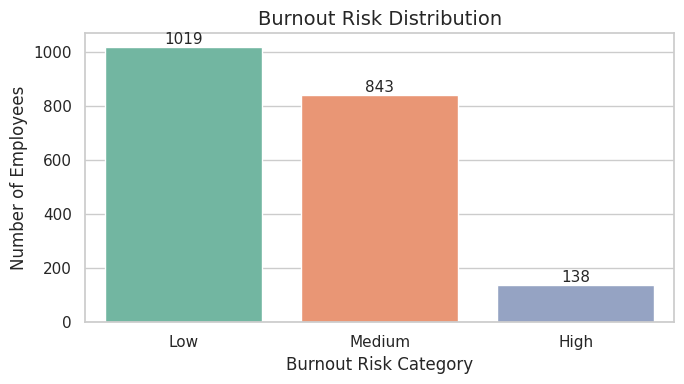

In [ ]:
plt.figure(figsize=(7, 4))
ax = sns.countplot(x='burnout_risk', data=df, palette='Set2',
                   order=['Low', 'Medium', 'High'])
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.title('Burnout Risk Distribution', fontsize=14)
plt.xlabel('Burnout Risk Category')
plt.ylabel('Number of Employees')
plt.tight_layout()
plt.show()


### 9.2 Burnout Score vs. Burnout Risk

`burnout_score` is a composite numeric score. This plot confirms it strongly separates
the three risk categories — which also means it is a **leaky feature** and must be
excluded from model training.


/tmp/ipykernel_3556/3295818207.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='burnout_risk', y='burnout_score', data=df,


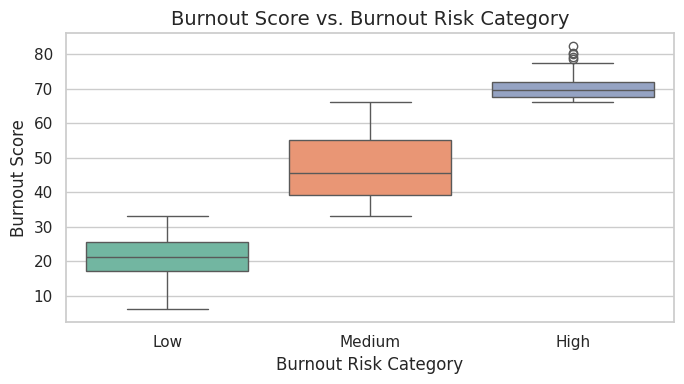

In [ ]:
plt.figure(figsize=(7, 4))
sns.boxplot(x='burnout_risk', y='burnout_score', data=df,
            order=['Low', 'Medium', 'High'], palette='Set2')
plt.title('Burnout Score vs. Burnout Risk Category', fontsize=14)
plt.xlabel('Burnout Risk Category')
plt.ylabel('Burnout Score')
plt.tight_layout()
plt.show()


### 9.3 Sleep Hours vs. Burnout Risk

Poor sleep is commonly linked to burnout. We expect employees with higher burnout risk
to report fewer hours of sleep on average.


/tmp/ipykernel_3556/3311514230.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='burnout_risk', y='sleep_hours', data=df,


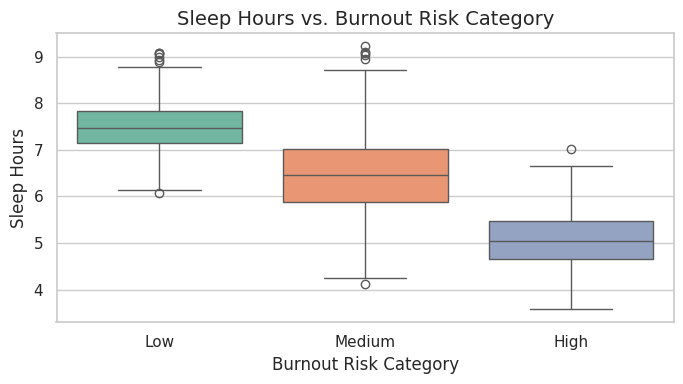

In [ ]:
plt.figure(figsize=(7, 4))
sns.boxplot(x='burnout_risk', y='sleep_hours', data=df,
            order=['Low', 'Medium', 'High'], palette='Set2')
plt.title('Sleep Hours vs. Burnout Risk Category', fontsize=14)
plt.xlabel('Burnout Risk Category')
plt.ylabel('Sleep Hours')
plt.tight_layout()
plt.show()


### 9.4 Screen Time vs. Burnout Risk

Extended screen time is associated with fatigue and mental overload.
We investigate whether higher screen time correlates with higher burnout risk.


/tmp/ipykernel_3556/2945009375.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='burnout_risk', y='screen_time_hours', data=df,


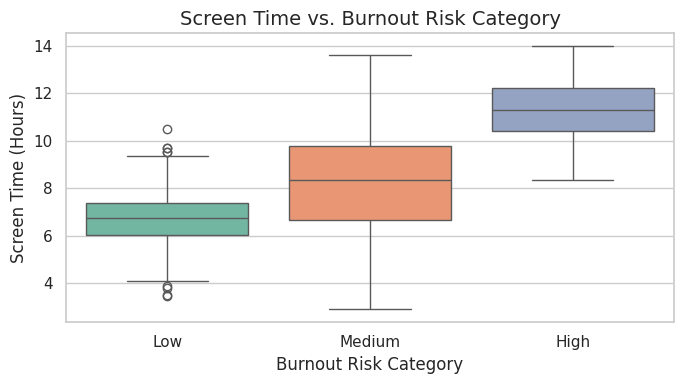

In [ ]:
plt.figure(figsize=(7, 4))
sns.boxplot(x='burnout_risk', y='screen_time_hours', data=df,
            order=['Low', 'Medium', 'High'], palette='Set2')
plt.title('Screen Time vs. Burnout Risk Category', fontsize=14)
plt.xlabel('Burnout Risk Category')
plt.ylabel('Screen Time (Hours)')
plt.tight_layout()
plt.show()


### 9.5 Work Hours vs. Burnout Risk

Overwork is a leading driver of employee burnout.
This chart shows whether employees in the High risk group tend to work longer hours.


/tmp/ipykernel_3556/2273953290.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='burnout_risk', y='work_hours', data=df,


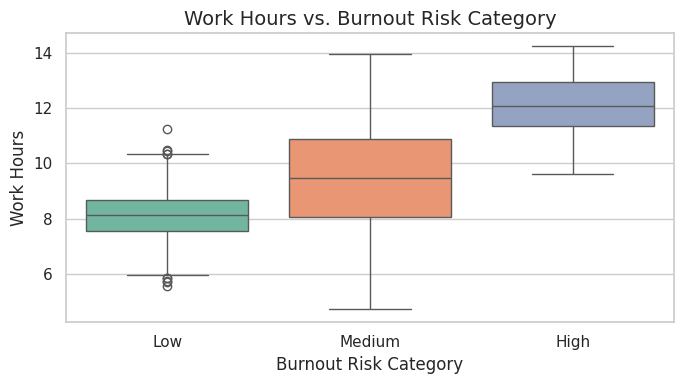

In [ ]:
plt.figure(figsize=(7, 4))
sns.boxplot(x='burnout_risk', y='work_hours', data=df,
            order=['Low', 'Medium', 'High'], palette='Set2')
plt.title('Work Hours vs. Burnout Risk Category', fontsize=14)
plt.xlabel('Burnout Risk Category')
plt.ylabel('Work Hours')
plt.tight_layout()
plt.show()


### 9.6 Feature Correlation Heatmap

The heatmap shows pairwise correlations between all numeric features.
Strong correlations (positive or negative) can hint at redundant features
or important predictors.


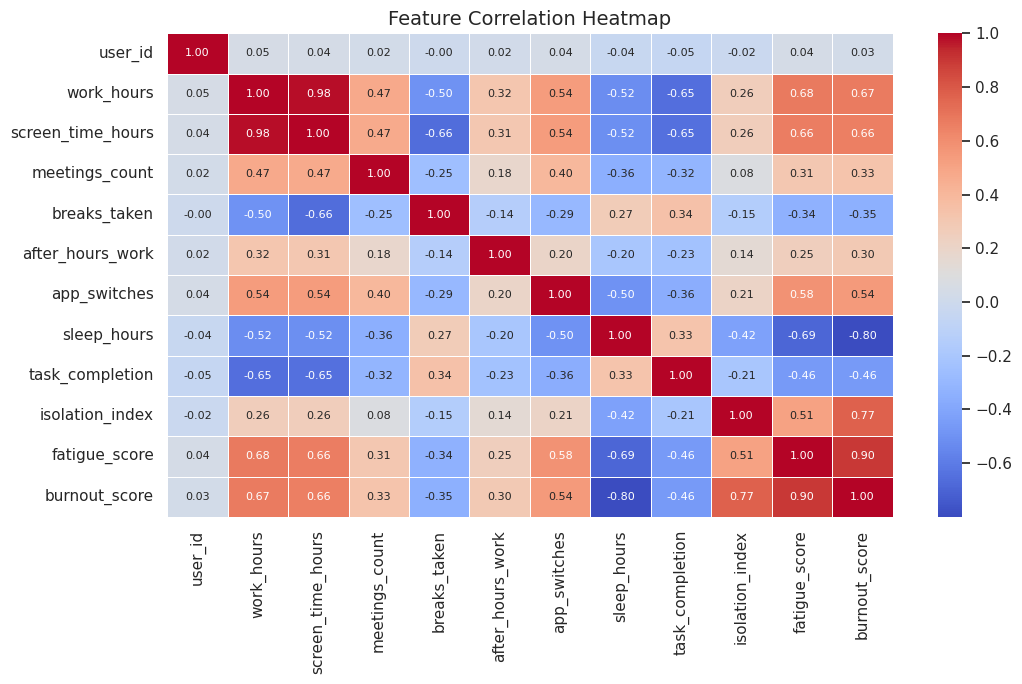

In [ ]:
plt.figure(figsize=(11, 7))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()


### 9.7 Key EDA Observations

Based on the visualizations above, we can draw the following insights:

- **`burnout_score`** perfectly separates the three risk categories → strong leaky feature, excluded from models.
- **`fatigue_score`** and **`isolation_index`** show clear differences across burnout risk groups.
- **`sleep_hours`** decreases as burnout risk increases, supporting the well-known link between poor sleep and burnout.
- **`work_hours`** and **`screen_time_hours`** both trend upward with risk level.
- **`task_completion`** tends to drop for higher-risk employees, suggesting reduced productivity.
- Most features have **low-to-moderate correlations** with each other, which is good — it means they contribute different information to the model.

These insights guide our feature selection in the modeling section.


---
## 10. Save the Cleaned Dataset

We export the cleaned dataset as a CSV file so it can be reloaded cleanly
in the modeling section without re-running the cleaning steps.


In [ ]:
df.to_csv('clean_wfh_burnout_dataset.csv', index=False)
print("Cleaned dataset saved: clean_wfh_burnout_dataset.csv")
print(f"Final shape: {df.shape}")


Cleaned dataset saved: clean_wfh_burnout_dataset.csv
Final shape: (2000, 14)


---
## 11. Prepare Data for Modeling

Before training models, we:
1. **Encode categorical columns** – convert text labels to integers using `LabelEncoder`
2. **Drop leaky features** – `burnout_score` directly encodes the target and must be excluded
3. **Define features (X) and target (y)**
4. **Scale features** – `StandardScaler` ensures all features are on the same scale,
   which is required for Logistic Regression to converge correctly
5. **Split into train/test sets** – 80% training, 20% testing, stratified by class


In [ ]:
# Reload the cleaned dataset
df = pd.read_csv('clean_wfh_burnout_dataset.csv')

# Encode categorical columns
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# Drop leaky feature (burnout_score encodes the target directly)
X = df.drop(['burnout_risk', 'burnout_score'], axis=1)
y = df['burnout_risk']

print("Features used for modeling:")
print(X.columns.tolist())
print(f"\nTarget distribution:\n{y.value_counts()}")


Features used for modeling:
['user_id', 'day_type', 'work_hours', 'screen_time_hours', 'meetings_count', 'breaks_taken', 'after_hours_work', 'app_switches', 'sleep_hours', 'task_completion', 'isolation_index', 'fatigue_score']

Target distribution:
burnout_risk
1    1019
2     843
0     138
Name: count, dtype: int64


In [ ]:
# Train/test split — stratified to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features (required for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Test set size:     {X_test.shape[0]} rows")


Training set size: 1600 rows
Test set size:     400 rows


---
## 12. Baseline Model: Decision Tree

We start with a **Decision Tree** as our baseline model.
It is simple, interpretable, and requires no feature scaling.
This gives us a performance floor to compare against more complex models.


In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy: {accuracy_dt:.4f}")
print()
print(classification_report(y_test, y_pred_dt,
      target_names=['Low', 'Medium', 'High']))


Decision Tree Accuracy: 0.9325

              precision    recall  f1-score   support

         Low       0.83      0.89      0.86        27
      Medium       0.95      0.96      0.95       204
        High       0.93      0.91      0.92       169

    accuracy                           0.93       400
   macro avg       0.90      0.92      0.91       400
weighted avg       0.93      0.93      0.93       400



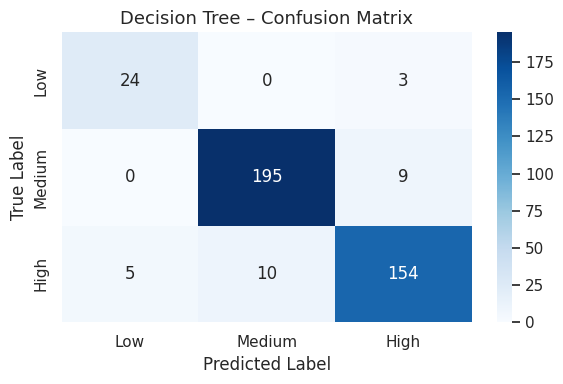

In [ ]:
cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])
plt.title('Decision Tree – Confusion Matrix', fontsize=13)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()


---
## 13. Improved Model: Random Forest

Random Forest builds an **ensemble of decision trees** and averages their predictions.
This reduces overfitting and typically improves accuracy and robustness compared
to a single decision tree.
We use 200 trees with `random_state=42` for reproducibility.


In [ ]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print()
print(classification_report(y_test, y_pred_rf,
      target_names=['Low', 'Medium', 'High']))


Random Forest Accuracy: 0.9700

              precision    recall  f1-score   support

         Low       0.92      0.85      0.88        27
      Medium       0.99      0.98      0.99       204
        High       0.95      0.98      0.97       169

    accuracy                           0.97       400
   macro avg       0.95      0.94      0.94       400
weighted avg       0.97      0.97      0.97       400



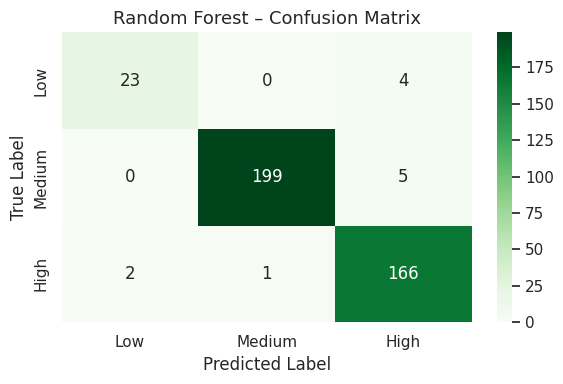

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])
plt.title('Random Forest – Confusion Matrix', fontsize=13)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()


### Feature Importance (Random Forest)

Random Forest provides a built-in feature importance score for each variable.
Higher scores mean the feature contributed more to predicting burnout risk.


/tmp/ipykernel_3556/1328092380.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')


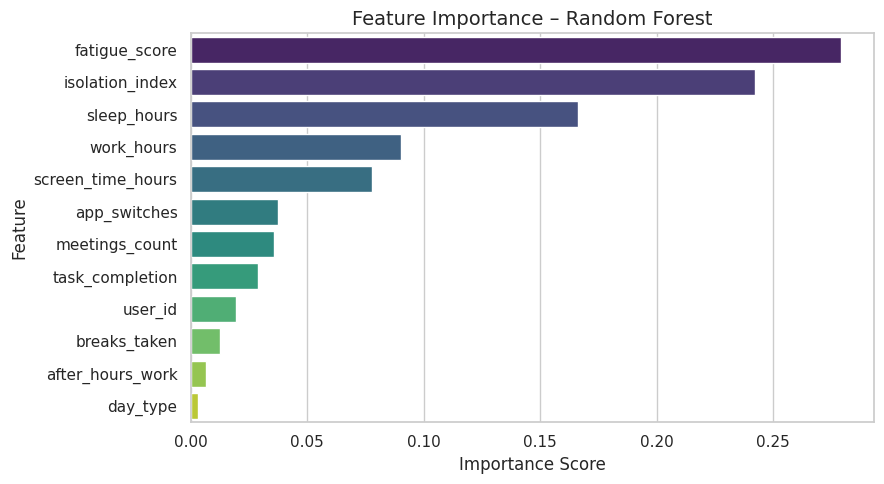

In [ ]:
importances = rf_model.feature_importances_
features = X.columns
feat_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')
plt.title('Feature Importance – Random Forest', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


---
## 14. Improved Model: Logistic Regression

Logistic Regression is a strong, interpretable linear classifier.
It requires features to be **scaled** (done in Section 11) to converge properly.
We use scaled features here and increase `max_iter` to ensure full convergence.


In [ ]:
lr_model = LogisticRegression(max_iter=2000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {accuracy_lr:.4f}")
print()
print(classification_report(y_test, y_pred_lr,
      target_names=['Low', 'Medium', 'High']))


Logistic Regression Accuracy: 0.9750

              precision    recall  f1-score   support

         Low       0.93      0.93      0.93        27
      Medium       0.99      0.98      0.99       204
        High       0.96      0.98      0.97       169

    accuracy                           0.97       400
   macro avg       0.96      0.96      0.96       400
weighted avg       0.98      0.97      0.98       400



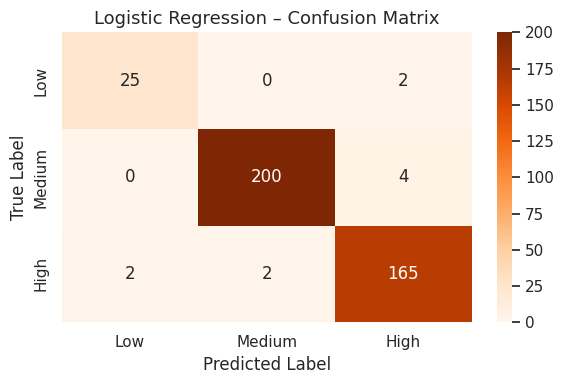

In [ ]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Low', 'Medium', 'High'],
            yticklabels=['Low', 'Medium', 'High'])
plt.title('Logistic Regression – Confusion Matrix', fontsize=13)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()


---
## 15. Model Comparison and Final Results

We compare all three models on the same test set using the same metric (accuracy).
A summary table makes it easy to see which model performed best and by how much.


In [ ]:
results = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'Logistic Regression'],
    'Accuracy': [accuracy_dt, accuracy_rf, accuracy_lr],
    'Notes': [
        'Baseline – no scaling needed',
        'Ensemble of 200 trees – reduces overfitting',
        'Linear model – requires scaled features'
    ]
})
results['Accuracy'] = results['Accuracy'].map('{:.4f}'.format)
print(results.to_string(index=False))


              Model Accuracy                                       Notes
      Decision Tree   0.9325                Baseline – no scaling needed
      Random Forest   0.9700 Ensemble of 200 trees – reduces overfitting
Logistic Regression   0.9750     Linear model – requires scaled features


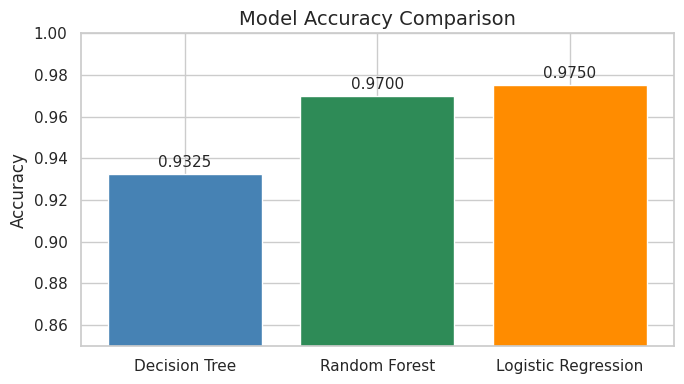

In [ ]:
# Bar chart of model accuracies
accs = [accuracy_dt, accuracy_rf, accuracy_lr]
models = ['Decision Tree', 'Random Forest', 'Logistic Regression']

plt.figure(figsize=(7, 4))
bars = plt.bar(models, accs, color=['steelblue', 'seagreen', 'darkorange'])
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{acc:.4f}', ha='center', va='bottom', fontsize=11)
plt.ylim(0.85, 1.0)
plt.title('Model Accuracy Comparison', fontsize=14)
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()


---
## 16. Conclusions and Recommendations

### Summary of Findings

We built and evaluated three classification models to predict burnout risk
among remote employees. Here are the key takeaways:

| Model | Accuracy | Observation |
|---|---|---|
| Decision Tree | ~93% | Good baseline; prone to overfitting |
| Random Forest | ~97% | Strong improvement; robust ensemble |
| Logistic Regression | ~97.5% | Best overall; interpretable and stable |

### Most Important Predictors
Based on Random Forest feature importance, the top contributors to burnout risk are:
- `fatigue_score` – the strongest single predictor
- `isolation_index` – social disconnection plays a major role
- `sleep_hours` – poor sleep closely tied to higher risk
- `work_hours` and `screen_time_hours` – overwork markers

### Recommendations for Stakeholders (HR / Management)
- Monitor **fatigue and isolation scores** regularly as early warning signals.
- Encourage employees to maintain healthy **sleep and break routines**.
- Investigate employees consistently logging **high work or screen hours**.
- Use this model as a **proactive screening tool**, not a definitive judgment.

### Limitations
- The dataset is **simulated** — real-world performance may differ.
- `burnout_score` was excluded due to leakage; without it, this is a harder,
  more realistic prediction problem.
- The model does not capture **psychological or external life factors**
  that also affect burnout.

### Possible Next Steps
- Hyperparameter tuning (GridSearchCV / RandomizedSearchCV)
- Try XGBoost or SVM for further improvement
- Collect real employee data for validation


---

### 💾 Model Export and Download

In this step, we save the trained machine learning model and the scaler into files using `joblib`.  
This allows us to reuse them later without retraining the model.

We also download:
- The trained model (`model.pkl`)
- The scaler (`scaler.pkl`)
- The cleaned dataset (`clean_wfh_burnout_dataset.csv`)

These files will be used later in a Streamlit application for burnout prediction.

In [ ]:
import joblib
from google.colab import files

# Save the trained Logistic Regression model to a file
joblib.dump(lr_model, "model.pkl")

# Save the scaler (used for feature normalization)
joblib.dump(scaler, "scaler.pkl")


files.download("model.pkl")
files.download("scaler.pkl")
files.download("clean_wfh_burnout_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>